In [1]:
# Task 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Improve visualization style
sns.set(style="whitegrid") 
# Task 2: Load the Dataset

df = pd.read_csv("Referral of Medical Cases 2025 Q1 CSV.csv")

print("Dataset Shape:", df.shape)
df.head(7)

Dataset Shape: (5501, 6)


,GENDER,REFERRING_PROVIDER_REGION,DISEASE_CODE,RECEIVING_PROVIDER_REGION,AGE_GROUP,TOTAL_REFERRALS
0,M,Riyadh,R56.8,Riyadh,40-49,30
1,M,Jeddah,K52.9,Jeddah,00-17,21
2,M,Jeddah,I10,Jeddah,40-49,20
3,F,Qassim,R06.0,Qassim,60-69,3
4,M,Jeddah,R07.4,Makkah,50-59,2
5,M,Jeddah,A78,Makkah,70-79,1
6,F,Makkah,R07.4,Makkah,50-59,6


In [2]:
# Task 3: General Information About the Dataset

df.info()
# Task 4: Descriptive Statistics for All Columns
df.describe(include="all").T
# Task 5: Check Data Types of Each Column
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5501 entries, 0 to 5500
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   GENDER                     5501 non-null   object
 1   REFERRING_PROVIDER_REGION  5501 non-null   object
 2   DISEASE_CODE               5501 non-null   object
 3   RECEIVING_PROVIDER_REGION  5501 non-null   object
 4   AGE_GROUP                  5501 non-null   object
 5   TOTAL_REFERRALS            5501 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 258.0+ KB


GENDER                       object
REFERRING_PROVIDER_REGION    object
DISEASE_CODE                 object
RECEIVING_PROVIDER_REGION    object
AGE_GROUP                    object
TOTAL_REFERRALS               int64
dtype: object

In [3]:
# Task 6: Data Cleaning and Standardization

# Remove extra spaces from column names
df.columns = [col.strip() for col in df.columns]

# Standardize text columns (remove leading/trailing spaces)
text_columns = [
    "GENDER",
    "REFERRING_PROVIDER_REGION",
    "DISEASE_CODE",
    "RECEIVING_PROVIDER_REGION",
    "AGE_GROUP"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

# Ensure TOTAL_REFERRALS is numeric
df["TOTAL_REFERRALS"] = pd.to_numeric(df["TOTAL_REFERRALS"], errors="coerce")

df.head()

,GENDER,REFERRING_PROVIDER_REGION,DISEASE_CODE,RECEIVING_PROVIDER_REGION,AGE_GROUP,TOTAL_REFERRALS
0,M,Riyadh,R56.8,Riyadh,40-49,30
1,M,Jeddah,K52.9,Jeddah,00-17,21
2,M,Jeddah,I10,Jeddah,40-49,20
3,F,Qassim,R06.0,Qassim,60-69,3
4,M,Jeddah,R07.4,Makkah,50-59,2


In [4]:
# Task 7: Check Missing Values and Duplicate Rows

print("Missing Values Per Column:")
print(df.isnull().sum())

print("\nNumber of Duplicate Rows:", df.duplicated().sum())

Missing Values Per Column:
GENDER                       0
REFERRING_PROVIDER_REGION    0
DISEASE_CODE                 0
RECEIVING_PROVIDER_REGION    0
AGE_GROUP                    0
TOTAL_REFERRALS              0
dtype: int64

Number of Duplicate Rows: 0


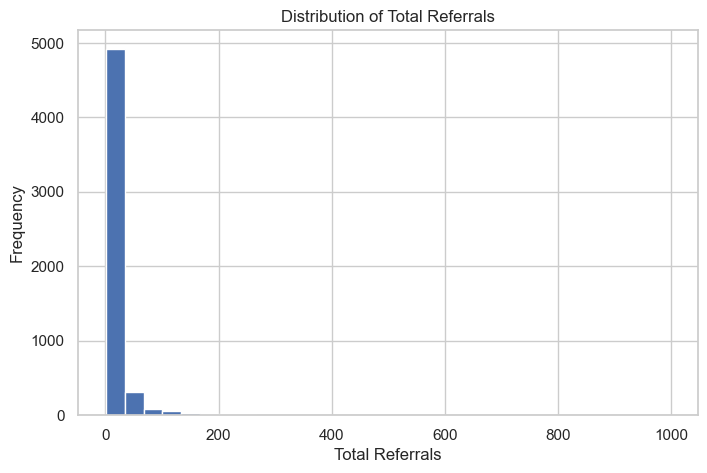

In [5]:
# Task 8: Distribution of TOTAL_REFERRALS

plt.figure(figsize=(8,5))
plt.hist(df["TOTAL_REFERRALS"].dropna(), bins=30)
plt.title("Distribution of Total Referrals")
plt.xlabel("Total Referrals")
plt.ylabel("Frequency")
plt.show()

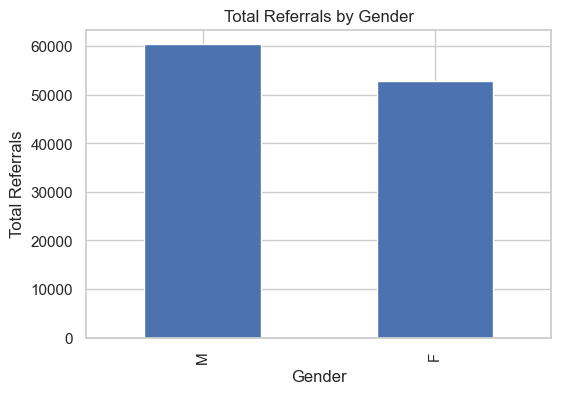

In [6]:
# Task 9: Total Referrals by Gender

gender_sum = df.groupby("GENDER")["TOTAL_REFERRALS"].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))
gender_sum.plot(kind="bar")
plt.title("Total Referrals by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Referrals")
plt.show()

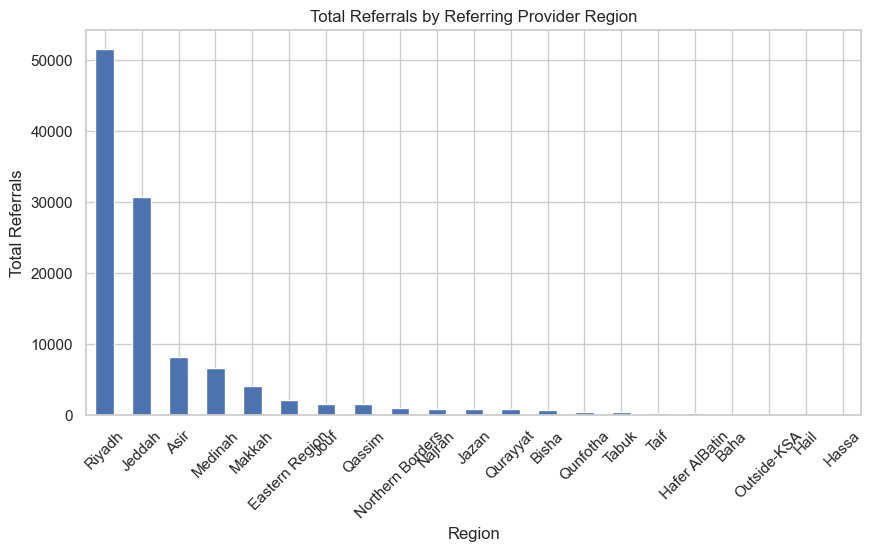

In [7]:
# Task 10: Total Referrals by Referring Provider Region

region_sum = df.groupby("REFERRING_PROVIDER_REGION")["TOTAL_REFERRALS"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
region_sum.plot(kind="bar")
plt.title("Total Referrals by Referring Provider Region")
plt.xlabel("Region")
plt.ylabel("Total Referrals")
plt.xticks(rotation=45)
plt.show()

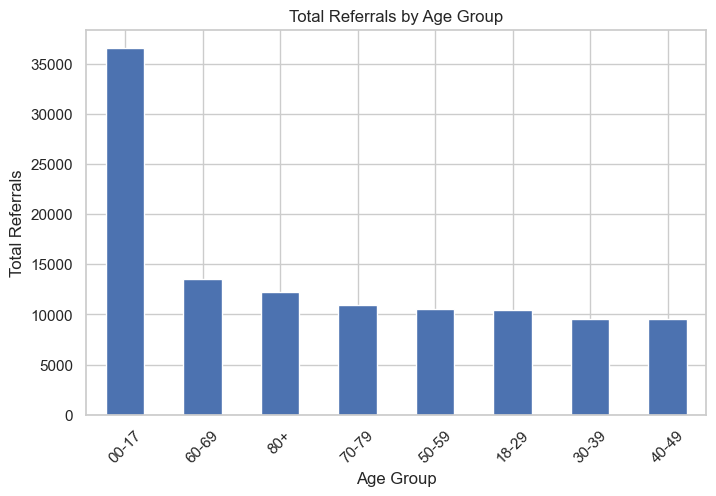

In [8]:
# Task 11: Total Referrals by Age Group

age_sum = df.groupby("AGE_GROUP")["TOTAL_REFERRALS"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
age_sum.plot(kind="bar")
plt.title("Total Referrals by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Referrals")
plt.xticks(rotation=45)
plt.show()

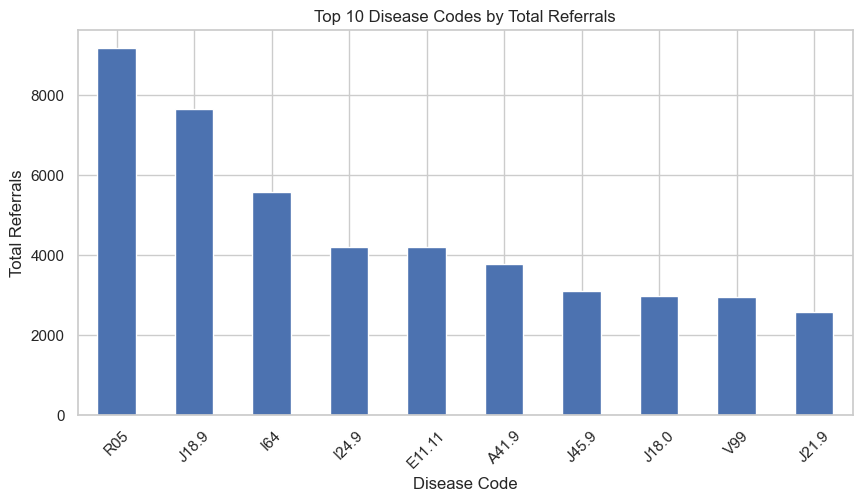

In [9]:
# Task 12: Top 10 Disease Codes by Total Referrals

disease_sum = df.groupby("DISEASE_CODE")["TOTAL_REFERRALS"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
disease_sum.plot(kind="bar")
plt.title("Top 10 Disease Codes by Total Referrals")
plt.xlabel("Disease Code")
plt.ylabel("Total Referrals")
plt.xticks(rotation=45)
plt.show()

In [11]:
# Task: Correlation Analysis

numeric_cols = df.select_dtypes(include=[np.number])

if numeric_cols.shape[1] > 1:
    plt.figure(figsize=(6,4))
    sns.heatmap(numeric_cols.corr(), annot=True, cmap="Blues")
    plt.title("Correlation Matrix")
    plt.show()
else:
    print("Correlation analysis is not applicable because the dataset contains only one numeric column.")

Correlation analysis is not applicable because the dataset contains only one numeric column.
